# 03 — Phân tích Cohort MoM Retention & FPU vs RPU

**Task T13** · Owner: Đào · Lan review · Phục vụ mục **3.3.2** (FPU vs RPU) và **3.3.3** (Cohort MoM Retention).

**Dữ liệu:** bộ BNPL tổng hợp của nhóm (`bnpl_transactions_clean.csv`, `bnpl_customers_clean.csv`,
`bnpl_customer_features.csv`) — 8.000 khách hàng, 64.746 giao dịch, log giao dịch năm 2024.
Định nghĩa churn theo T02: `churn_60d = 1` nếu `recency_days ≥ 60` tại mốc quan sát 30/12/2024.

**Notebook trả lời 4 câu hỏi:**
1. Tỷ lệ khách của từng thế hệ (cohort theo tháng giao dịch đầu tiên) còn hoạt động sau *n* tháng?
2. Khách rơi rớt mạnh nhất ở giai đoạn nào của vòng đời → "cửa sổ vàng" can thiệp?
3. FPU (mua 1 lần) so với RPU (mua lặp lại) khác nhau thế nào về quy mô và nguy cơ rời bỏ?
4. Danh mục thanh toán nào giữ chân tốt nhất — *insight chính của đề tài*.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="DejaVu Sans")

DATA_DIR = "../data"
FIG_DIR = "../reports/figures"
os.makedirs(FIG_DIR, exist_ok=True)

tx = pd.read_csv(f"{DATA_DIR}/bnpl_transactions_clean.csv", parse_dates=["transaction_date"])
cust = pd.read_csv(f"{DATA_DIR}/bnpl_customers_clean.csv", parse_dates=["activation_date"])
feat = pd.read_csv(f"{DATA_DIR}/bnpl_customer_features.csv",
                   parse_dates=["activation_date", "first_trx_date", "last_trx_date"])

OBS_DATE = pd.Timestamp("2024-12-30")   # mốc quan sát (suy ra từ last_trx_date + recency_days)
CHURN_COL = "churn_60d"                 # theo T02 — cửa sổ bất hoạt 60 ngày

print(f"Giao dịch : {len(tx):,} | {tx.transaction_date.min():%d/%m/%Y} → {tx.transaction_date.max():%d/%m/%Y}")
print(f"Khách hàng: {len(cust):,} (đăng ký) | {tx.customer_id.nunique():,} có ít nhất 1 giao dịch")
print(f"Mốc quan sát: {OBS_DATE:%d/%m/%Y} | Nhãn churn: {CHURN_COL} (recency ≥ 60 ngày)")
tx.head(3)

Giao dịch : 64,746 | 01/01/2024 → 29/12/2024
Khách hàng: 8,000 (đăng ký) | 7,024 có ít nhất 1 giao dịch
Mốc quan sát: 30/12/2024 | Nhãn churn: churn_60d (recency ≥ 60 ngày)


,transaction_id,customer_id,transaction_date,payment_category,payment_mode,amount_vnd,repayment_status,promo_applied,is_suspicious_flag,ym,has_suspicious
0,TRX00000001,ZLP000002,2024-01-07 22:06:50,Chăm sóc sức khỏe,ZaloPay Balance,392000.0,OnTime,No Promo,0,2024-01,0
1,TRX00000002,ZLP000002,2024-02-11 23:26:01,Chăm sóc sức khỏe,ZaloPay Balance,153000.0,OnTime,No Promo,0,2024-02,0
2,TRX00000003,ZLP000002,2024-03-20 19:27:27,Chăm sóc sức khỏe,ZaloPay Balance,472000.0,OnTime,No Promo,0,2024-03,0


## 1. Xác định tập phân tích cohort — xử lý hiện tượng cắt cụt bên trái (left truncation)

⚠️ **Vấn đề cần xử lý trước khi dựng cohort.** Log giao dịch chỉ bắt đầu từ 01/01/2024, trong khi
`activation_date` của khách hàng trải từ 01/2023. Hệ quả: mọi khách kích hoạt trong năm 2023 đều có
"giao dịch đầu tiên quan sát được" rơi vào tháng 01/2024 — nhưng đó **không phải** giao dịch đầu tiên
thật sự của họ. Nếu gộp chung, cohort tháng 01/2024 sẽ là hỗn hợp giữa khách thật sự mới và khách đã
gắn bó cả năm, làm sai lệch toàn bộ ma trận retention.

**Cách xử lý:** chỉ đưa vào phân tích cohort những khách hàng **kích hoạt từ 01/01/2024 trở đi** — nhóm
có toàn bộ vòng đời nằm trong cửa sổ dữ liệu. Nhóm kích hoạt trước 2024 được báo cáo riêng ở mức tham khảo.

In [2]:
tx["txn_month"] = tx.transaction_date.dt.to_period("M")
first_txn = tx.groupby("customer_id")["transaction_date"].min()

has_txn = feat[feat.lifecycle_segment != "No_Transaction"].copy()
truncated = has_txn[has_txn.activation_date < "2024-01-01"]
cohort_pool = has_txn[has_txn.activation_date >= "2024-01-01"]

print(f"Khách có giao dịch                     : {len(has_txn):,}")
print(f"  ├─ kích hoạt TRƯỚC 2024 (bị cắt cụt) : {len(truncated):,} ({len(truncated)/len(has_txn):.1%}) → loại khỏi cohort")
print(f"  └─ kích hoạt trong 2024 (dùng cohort): {len(cohort_pool):,} ({len(cohort_pool)/len(has_txn):.1%})")
print(f"\nKhách đăng ký nhưng CHƯA từng giao dịch: {(feat.lifecycle_segment == 'No_Transaction').sum():,}"
      f" — nhóm 'kích hoạt hụt', phân tích riêng ở mục 3.3.2")

tx_c = tx[tx.customer_id.isin(cohort_pool.customer_id)].copy()
tx_c["cohort_month"] = tx_c.customer_id.map(first_txn.dt.to_period("M"))
tx_c["period_index"] = (tx_c.txn_month - tx_c.cohort_month).apply(lambda p: p.n)

cohort_sizes = tx_c.groupby("cohort_month")["customer_id"].nunique().rename("Quy mô cohort")
cohort_sizes.to_frame().T

Khách có giao dịch                     : 7,024
  ├─ kích hoạt TRƯỚC 2024 (bị cắt cụt) : 3,069 (43.7%) → loại khỏi cohort
  └─ kích hoạt trong 2024 (dùng cohort): 3,955 (56.3%)

Khách đăng ký nhưng CHƯA từng giao dịch: 976 — nhóm 'kích hoạt hụt', phân tích riêng ở mục 3.3.2


cohort_month,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12
Quy mô cohort,728,316,407,401,411,349,380,318,264,118,181,82


## 2. Ma trận Cohort MoM Retention (Cohort Triangle) — mục 3.3.3

`Retention(c, n)` = số khách của cohort *c* còn phát sinh giao dịch ở tháng thứ *n* ÷ quy mô cohort *c*.
Theo định nghĩa, cột tháng 0 luôn bằng 100%.

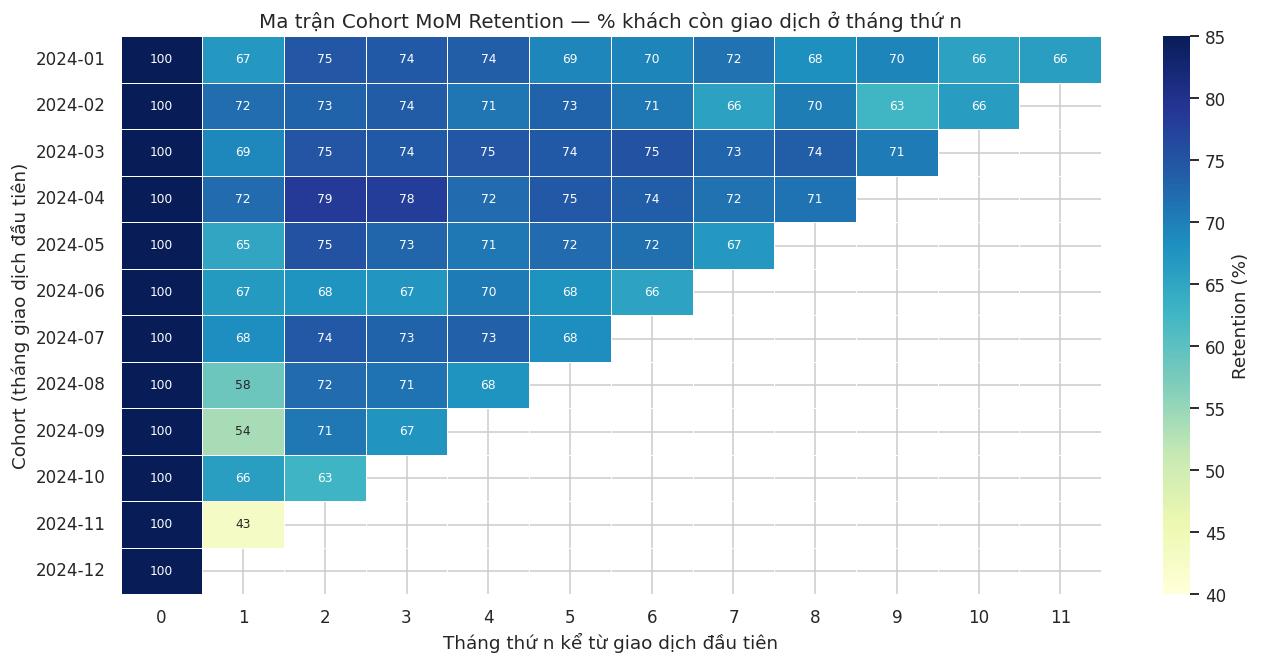

Quy mô từng cohort: {Period('2024-01', 'M'): 728, Period('2024-02', 'M'): 316, Period('2024-03', 'M'): 407, Period('2024-04', 'M'): 401, Period('2024-05', 'M'): 411, Period('2024-06', 'M'): 349, Period('2024-07', 'M'): 380, Period('2024-08', 'M'): 318, Period('2024-09', 'M'): 264, Period('2024-10', 'M'): 118, Period('2024-11', 'M'): 181, Period('2024-12', 'M'): 82}


In [3]:
active = (tx_c.groupby(["cohort_month", "period_index"])["customer_id"]
              .nunique().reset_index(name="n_active"))
retention = active.pivot(index="cohort_month", columns="period_index", values="n_active")
retention_pct = retention.divide(cohort_sizes, axis=0) * 100

fig, ax = plt.subplots(figsize=(12.5, 6.2))
sns.heatmap(retention_pct, annot=True, fmt=".0f", cmap="YlGnBu", vmin=40, vmax=85,
            cbar_kws={"label": "Retention (%)"}, annot_kws={"size": 8}, linewidths=0.4, ax=ax)
ax.set_title("Ma trận Cohort MoM Retention — % khách còn giao dịch ở tháng thứ n", fontsize=13)
ax.set_xlabel("Tháng thứ n kể từ giao dịch đầu tiên")
ax.set_ylabel("Cohort (tháng giao dịch đầu tiên)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/cohort_retention_heatmap.png", bbox_inches="tight")
plt.show()

print("Quy mô từng cohort:", cohort_sizes.to_dict())

**Cách đọc ma trận (đưa vào mục 3.3.3):**
- **Theo hàng** — đường cong "sống sót" của một thế hệ khách hàng theo vòng đời.
- **Theo cột** — so sánh chất lượng các cohort ở cùng độ tuổi (cohort nào giữ chân tốt hơn).
- **Theo đường chéo** — hiệu ứng thời gian lịch (mùa vụ, chiến dịch) tác động lên mọi cohort cùng lúc.

⚠️ Các cohort tháng 10–12/2024 bị **cắt cụt bên phải (right-censored)** — chỉ quan sát được 1–3 tháng
vòng đời, đồng thời quy mô nhỏ, nên chỉ dùng ở mức tham khảo (đúng lưu ý đã ghi ở mục 2.2.1c).

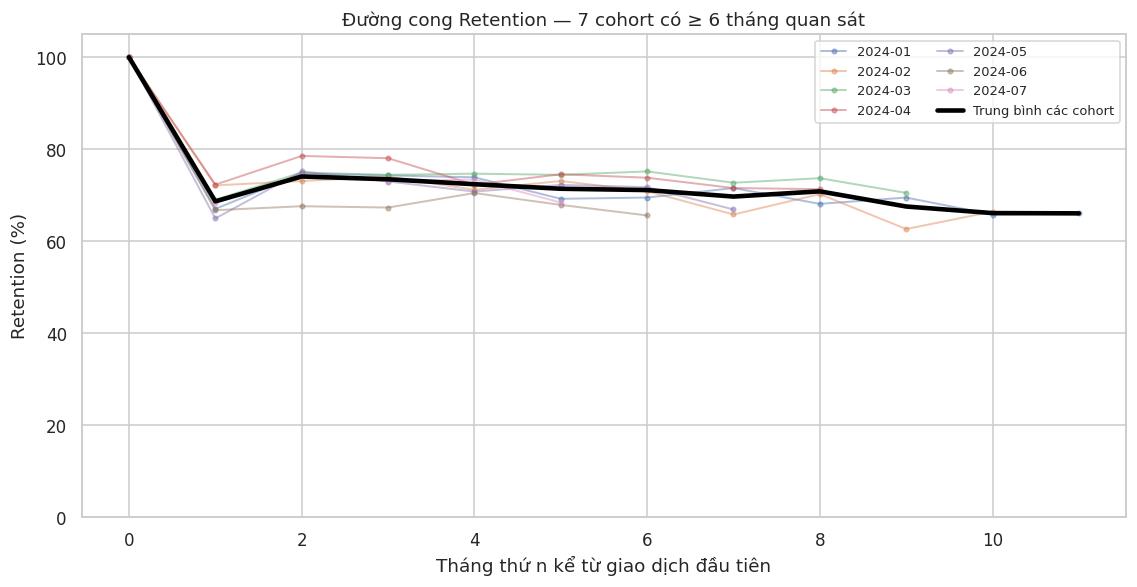

Retention trung bình — tháng 1: 68.7% | tháng 3: 73.5% | tháng 6: 71.1%
→ Sụt giảm lớn nhất diễn ra ngay trong tháng đầu: mất 31.3% khách của cohort.
→ Sau đó đường cong đi ngang quanh mức 73% — nhóm vượt qua tháng đầu có xu hướng ở lại lâu dài.


In [4]:
MATURE_MIN_PERIODS = 6      # cohort "chín" = quan sát được ít nhất 6 tháng vòng đời
mature = retention_pct[retention_pct.notna().sum(axis=1) >= MATURE_MIN_PERIODS]
mean_curve = mature.mean(axis=0)

fig, ax = plt.subplots(figsize=(10.5, 5.5))
for c in mature.index:
    ax.plot(mature.columns, mature.loc[c], alpha=0.45, lw=1.3, marker="o", ms=3, label=str(c))
ax.plot(mean_curve.index, mean_curve.values, color="black", lw=3, label="Trung bình các cohort")
ax.set_ylim(0, 105)
ax.set_xlabel("Tháng thứ n kể từ giao dịch đầu tiên")
ax.set_ylabel("Retention (%)")
ax.set_title(f"Đường cong Retention — {len(mature)} cohort có ≥ {MATURE_MIN_PERIODS} tháng quan sát")
ax.legend(ncol=2, fontsize=8.5)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/cohort_retention_curves.png", bbox_inches="tight")
plt.show()

m1, m3, m6 = (float(mean_curve.get(k, np.nan)) for k in (1, 3, 6))
print(f"Retention trung bình — tháng 1: {m1:.1f}% | tháng 3: {m3:.1f}% | tháng 6: {m6:.1f}%")
print(f"→ Sụt giảm lớn nhất diễn ra ngay trong tháng đầu: mất {100 - m1:.1f}% khách của cohort.")
print(f"→ Sau đó đường cong đi ngang quanh mức {mean_curve[2:7].mean():.0f}% — nhóm vượt qua tháng đầu "
      f"có xu hướng ở lại lâu dài.")

### 2.1. Kiểm chứng: retention theo cửa sổ 30 ngày neo tại từng khách hàng

Cohort theo **tháng lịch** có một nhược điểm đã biết: khách giao dịch lần đầu vào cuối tháng chỉ còn vài
ngày của "tháng 0", nên dễ bị tính là mất ở tháng 1 dù thực tế họ quay lại sau 3–4 tuần. Để loại trừ
khả năng cú sụt ở tháng 1 chỉ là *ảo ảnh do cách chia tháng*, ta tính lại retention theo **cửa sổ 30 ngày
neo tại ngày giao dịch đầu tiên của chính khách hàng đó**, và chỉ đưa vào mẫu số những khách đã được
quan sát đủ cửa sổ tương ứng.

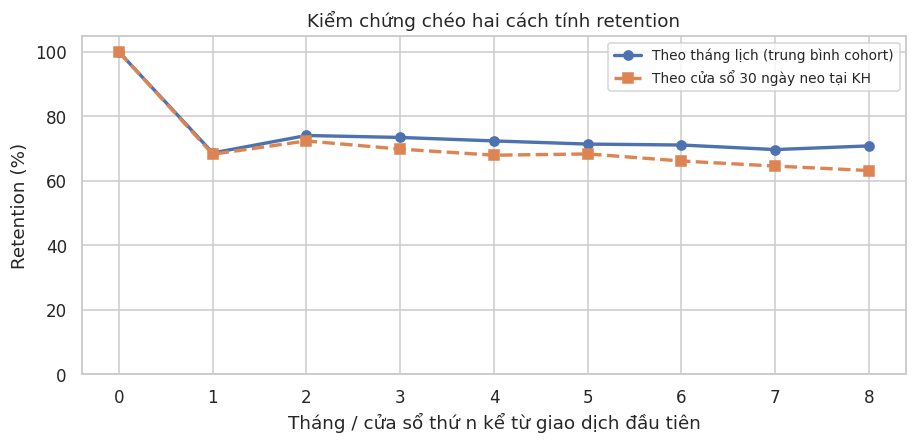

Retention theo cửa sổ 30 ngày: {0: 100.0, 1: 68.3, 2: 72.4, 3: 69.9, 4: 68.0, 5: 68.4, 6: 66.2, 7: 64.6, 8: 63.2}
→ Hai cách tính cho cùng một hình dạng (sụt ở kỳ 1 rồi đi ngang) ⇒ cú sụt tháng đầu là **đặc điểm thật của dữ liệu**, không phải ảo ảnh do chia tháng lịch.


In [5]:
tx_c["win_index"] = ((tx_c.transaction_date - tx_c.customer_id.map(first_txn)).dt.days // 30).astype(int)
obs_windows = ((OBS_DATE - first_txn.loc[cohort_pool.customer_id.values]).dt.days // 30)

win_curve = {}
for n in range(0, 9):
    eligible = obs_windows[obs_windows >= n].index
    n_active = tx_c[(tx_c.win_index == n) & (tx_c.customer_id.isin(eligible))].customer_id.nunique()
    win_curve[n] = n_active / len(eligible) * 100 if len(eligible) else np.nan
win_curve = pd.Series(win_curve)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(mean_curve.index[:9], mean_curve.values[:9], marker="o", lw=2.2,
        label="Theo tháng lịch (trung bình cohort)")
ax.plot(win_curve.index, win_curve.values, marker="s", lw=2.2, ls="--",
        label="Theo cửa sổ 30 ngày neo tại KH")
ax.set_ylim(0, 105)
ax.set_xlabel("Tháng / cửa sổ thứ n kể từ giao dịch đầu tiên")
ax.set_ylabel("Retention (%)")
ax.set_title("Kiểm chứng chéo hai cách tính retention")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/retention_crosscheck.png", bbox_inches="tight")
plt.show()

print("Retention theo cửa sổ 30 ngày:", win_curve.round(1).to_dict())
print(f"→ Hai cách tính cho cùng một hình dạng (sụt ở kỳ 1 rồi đi ngang) ⇒ cú sụt tháng đầu là "
      f"**đặc điểm thật của dữ liệu**, không phải ảo ảnh do chia tháng lịch.")

## 3. FPU vs RPU — mục 3.3.2

- **FPU (First Paying User)**: khách chỉ phát sinh **đúng 1** giao dịch BNPL.
- **RPU (Repeat Paying User)**: khách có **≥ 2** giao dịch; bộ dữ liệu chia tiếp thành
  `RPU_Early` (2–5 giao dịch), `RPU_Mid` (6–15) và `RPU_Loyal` (> 15).
- Ngoài ra còn nhóm **No_Transaction**: đã đăng ký/được cấp hạn mức nhưng chưa từng giao dịch —
  thất bại ở khâu kích hoạt, cần tách riêng khi tính tỷ lệ churn.

In [6]:
seg_order = ["No_Transaction", "FPU", "RPU_Early", "RPU_Mid", "RPU_Loyal"]
seg = (feat.groupby("lifecycle_segment")
           .agg(so_khach=("customer_id", "size"), churn_rate=(CHURN_COL, "mean"))
           .reindex(seg_order))
seg["ty_trong_%"] = (seg.so_khach / seg.so_khach.sum() * 100).round(1)
seg["churn_rate_%"] = (seg.churn_rate * 100).round(1)
seg = seg[["so_khach", "ty_trong_%", "churn_rate_%"]]

fpu_n = int(seg.loc["FPU", "so_khach"])
rpu_n = int(seg.loc[["RPU_Early", "RPU_Mid", "RPU_Loyal"], "so_khach"].sum())
print(f"FPU (đúng 1 giao dịch): {fpu_n:,} khách ({fpu_n/(fpu_n+rpu_n):.1%} số khách có giao dịch)")
print(f"RPU (≥ 2 giao dịch)   : {rpu_n:,} khách ({rpu_n/(fpu_n+rpu_n):.1%})")
print(f"Tỷ lệ chuyển đổi FPU → RPU: {rpu_n/(fpu_n+rpu_n):.1%}\n")
seg

FPU (đúng 1 giao dịch): 465 khách (6.6% số khách có giao dịch)
RPU (≥ 2 giao dịch)   : 6,559 khách (93.4%)
Tỷ lệ chuyển đổi FPU → RPU: 93.4%



,so_khach,ty_trong_%,churn_rate_%
lifecycle_segment,,,
No_Transaction,976,12.2,100.0
FPU,465,5.8,67.5
RPU_Early,1816,22.7,38.8
RPU_Mid,3882,48.5,5.4
RPU_Loyal,861,10.8,0.7


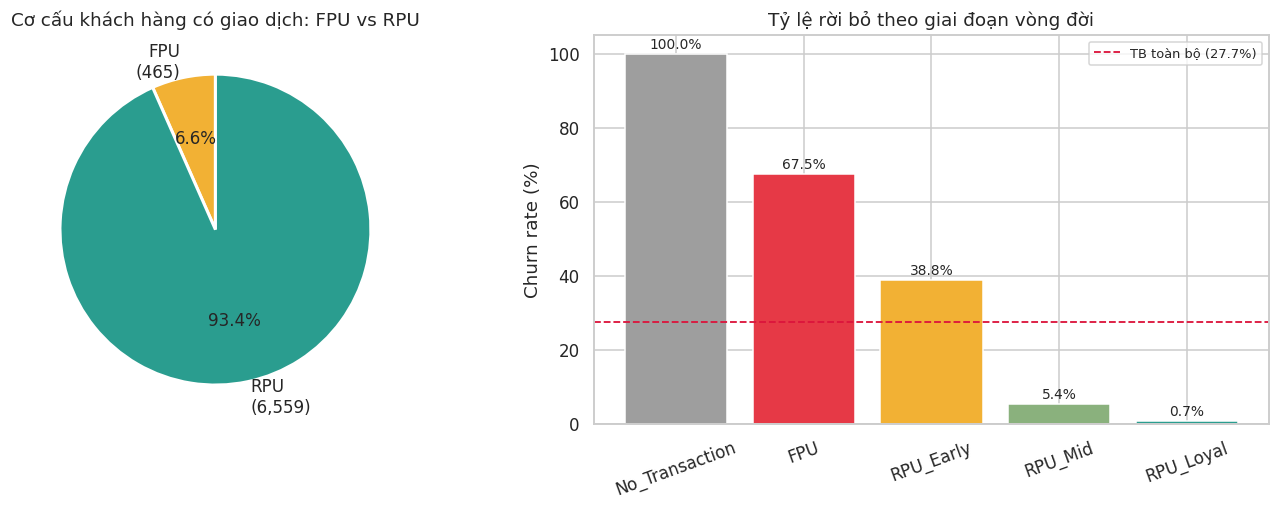

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].pie([fpu_n, rpu_n], labels=[f"FPU\n({fpu_n:,})", f"RPU\n({rpu_n:,})"],
            autopct="%1.1f%%", colors=["#f2b134", "#2a9d8f"], startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2}, textprops={"fontsize": 11})
axes[0].set_title("Cơ cấu khách hàng có giao dịch: FPU vs RPU")

bars = axes[1].bar(seg.index, seg["churn_rate_%"],
                   color=["#9e9e9e", "#e63946", "#f2b134", "#8ab17d", "#2a9d8f"])
axes[1].axhline(feat[CHURN_COL].mean() * 100, color="crimson", ls="--", lw=1.2,
                label=f"TB toàn bộ ({feat[CHURN_COL].mean()*100:.1f}%)")
for b, v in zip(bars, seg["churn_rate_%"]):
    axes[1].text(b.get_x() + b.get_width()/2, v + 1.5, f"{v:.1f}%", ha="center", fontsize=9)
axes[1].set_ylabel("Churn rate (%)")
axes[1].set_title("Tỷ lệ rời bỏ theo giai đoạn vòng đời")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(fontsize=8.5)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fpu_rpu_analysis.png", bbox_inches="tight")
plt.show()

### 3.1. Thời gian đến giao dịch thứ hai — chỉ báo sớm của retention

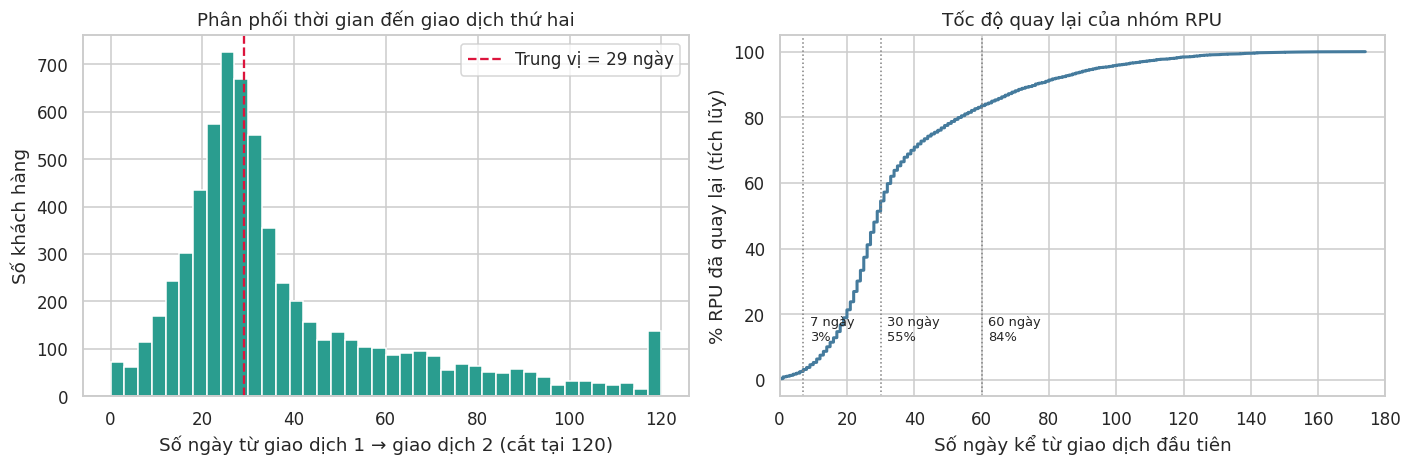

Thời gian đến giao dịch thứ 2 — trung vị 29 ngày | p75 46 ngày | p90 76 ngày
Tỷ lệ RPU quay lại trong 7 ngày: 3.2% | 30 ngày: 54.5% | 60 ngày: 83.5%


In [8]:
first_two = (tx.sort_values(["customer_id", "transaction_date"])
               .groupby("customer_id").head(2)
               .groupby("customer_id")["transaction_date"].agg(["first", "last"]))
first_two = first_two[first_two["first"] != first_two["last"]]   # chỉ giữ khách có ≥ 2 giao dịch
gap = (first_two["last"] - first_two["first"]).dt.days

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].hist(gap.clip(upper=120), bins=40, color="#2a9d8f", edgecolor="white")
axes[0].axvline(gap.median(), color="crimson", ls="--", lw=1.5,
                label=f"Trung vị = {gap.median():.0f} ngày")
axes[0].set_xlabel("Số ngày từ giao dịch 1 → giao dịch 2 (cắt tại 120)")
axes[0].set_ylabel("Số khách hàng")
axes[0].set_title("Phân phối thời gian đến giao dịch thứ hai")
axes[0].legend()

cum = np.arange(1, len(gap) + 1) / len(gap) * 100
axes[1].plot(np.sort(gap), cum, color="#457b9d", lw=2)
for d in (7, 30, 60):
    pct = (gap <= d).mean() * 100
    axes[1].axvline(d, color="grey", ls=":", lw=1)
    axes[1].text(d + 2, 12, f"{d} ngày\n{pct:.0f}%", fontsize=8.5)
axes[1].set_xlim(0, 180)
axes[1].set_xlabel("Số ngày kể từ giao dịch đầu tiên")
axes[1].set_ylabel("% RPU đã quay lại (tích lũy)")
axes[1].set_title("Tốc độ quay lại của nhóm RPU")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/time_to_second_purchase.png", bbox_inches="tight")
plt.show()

print(f"Thời gian đến giao dịch thứ 2 — trung vị {gap.median():.0f} ngày | "
      f"p75 {gap.quantile(0.75):.0f} ngày | p90 {gap.quantile(0.90):.0f} ngày")
print(f"Tỷ lệ RPU quay lại trong 7 ngày: {(gap <= 7).mean():.1%} | "
      f"30 ngày: {(gap <= 30).mean():.1%} | 60 ngày: {(gap <= 60).mean():.1%}")

## 4. Người dùng hoạt động hằng tháng (MAU): khách MỚI vs khách QUAY LẠI

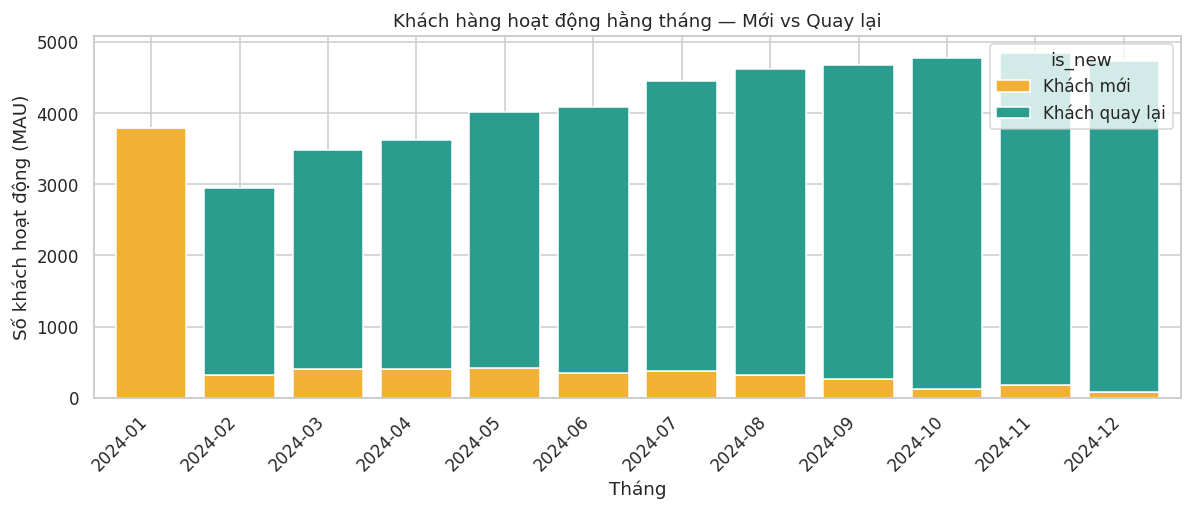

Tỷ trọng khách quay lại trong MAU (6 tháng cuối): {'2024-07': 91.5, '2024-08': 93.1, '2024-09': 94.4, '2024-10': 97.5, '2024-11': 96.3, '2024-12': 98.3}


In [9]:
tx["is_new"] = tx.customer_id.map(first_txn.dt.to_period("M")) == tx.txn_month
monthly = (tx.groupby(["txn_month", "is_new"])["customer_id"].nunique()
             .unstack(fill_value=0)
             .rename(columns={True: "Khách mới", False: "Khách quay lại"})[["Khách mới", "Khách quay lại"]])

ax = monthly.plot(kind="bar", stacked=True, figsize=(11, 4.8),
                  color=["#f2b134", "#2a9d8f"], width=0.8)
ax.set_title("Khách hàng hoạt động hằng tháng — Mới vs Quay lại")
ax.set_xlabel("Tháng"); ax.set_ylabel("Số khách hoạt động (MAU)")
ax.set_xticklabels([str(p) for p in monthly.index], rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/mau_new_vs_returning.png", bbox_inches="tight")
plt.show()

share = (monthly["Khách quay lại"] / monthly.sum(axis=1) * 100).round(1)
print("Tỷ trọng khách quay lại trong MAU (6 tháng cuối):",
      {str(k): v for k, v in share.tail(6).items()})

## 5. Retention theo danh mục thanh toán — insight chính của đề tài

Ghép chiều **danh mục** vào phân tích cohort: nhóm khách theo `top_category` (danh mục chi tiêu nhiều
nhất) rồi so sánh đường cong retention và tỷ lệ churn giữa các danh mục.

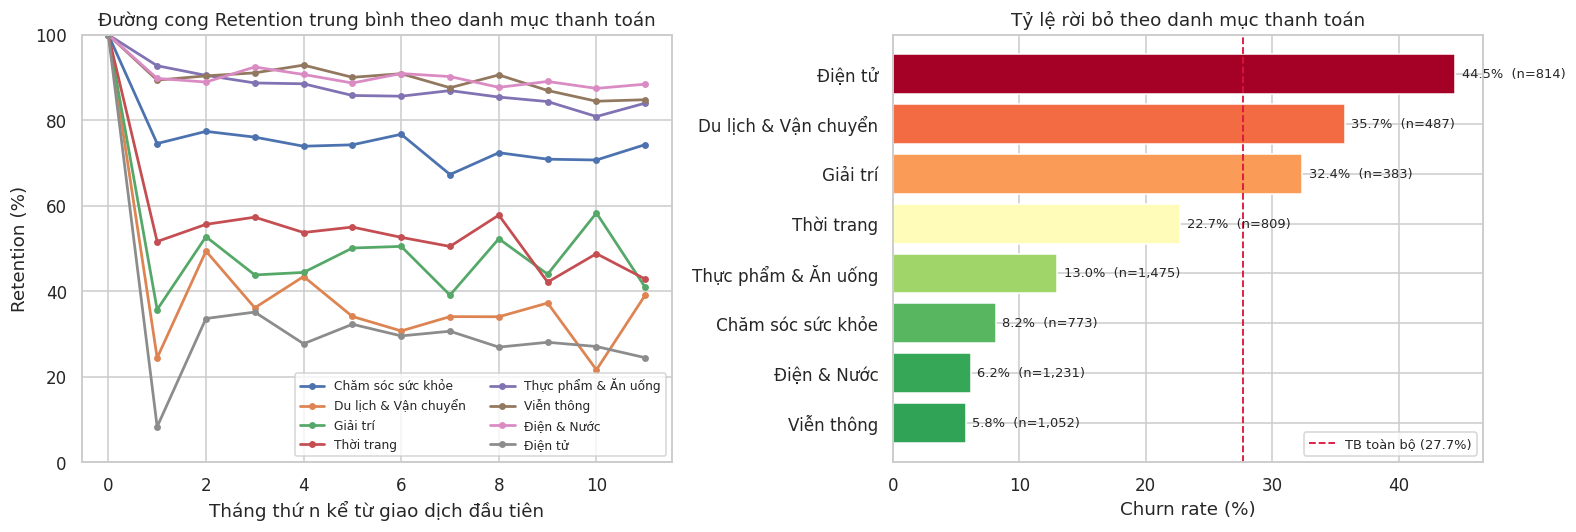

,churn_rate,n
top_category,,
Viễn thông,5.8,1052
Điện & Nước,6.2,1231
Chăm sóc sức khỏe,8.2,773
Thực phẩm & Ăn uống,13.0,1475
Thời trang,22.7,809
Giải trí,32.4,383
Du lịch & Vận chuyển,35.7,487
Điện tử,44.5,814


In [10]:
cat_of = feat.set_index("customer_id")["top_category"]
tx_c["cat"] = tx_c.customer_id.map(cat_of)

rows = []
for cat, grp in tx_c.groupby("cat"):
    size = grp.groupby("cohort_month")["customer_id"].nunique()
    act_ = grp.groupby(["cohort_month", "period_index"])["customer_id"].nunique().unstack()
    pct = (act_.divide(size, axis=0) * 100)
    pct = pct[pct.notna().sum(axis=1) >= MATURE_MIN_PERIODS]
    if len(pct):
        rows.append(pct.mean(axis=0).rename(cat))
cat_curves = pd.DataFrame(rows)

churn_by_cat = (feat.dropna(subset=["top_category"])
                    .groupby("top_category")[CHURN_COL]
                    .agg(churn_rate=lambda s: s.mean() * 100, n="size")
                    .sort_values("churn_rate"))

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5))
for cat in cat_curves.index:
    axes[0].plot(cat_curves.columns, cat_curves.loc[cat], marker="o", ms=3.5, lw=1.8, label=cat)
axes[0].set_xlabel("Tháng thứ n kể từ giao dịch đầu tiên")
axes[0].set_ylabel("Retention (%)")
axes[0].set_title("Đường cong Retention trung bình theo danh mục thanh toán")
axes[0].legend(fontsize=8, ncol=2)
axes[0].set_ylim(0, 100)

colors = plt.cm.RdYlGn_r(churn_by_cat.churn_rate / churn_by_cat.churn_rate.max())
axes[1].barh(churn_by_cat.index, churn_by_cat.churn_rate, color=colors)
axes[1].axvline(feat[CHURN_COL].mean() * 100, color="crimson", ls="--", lw=1.2,
                label=f"TB toàn bộ ({feat[CHURN_COL].mean()*100:.1f}%)")
for i, (v, n) in enumerate(zip(churn_by_cat.churn_rate, churn_by_cat.n)):
    axes[1].text(v + 0.5, i, f"{v:.1f}%  (n={n:,})", va="center", fontsize=8.5)
axes[1].set_xlabel("Churn rate (%)")
axes[1].set_title("Tỷ lệ rời bỏ theo danh mục thanh toán")
axes[1].legend(fontsize=8.5)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/retention_by_category.png", bbox_inches="tight")
plt.show()

churn_by_cat.round(1)

## 6. Xuất số liệu cho báo cáo

In [11]:
retention_pct.round(1).to_csv("../reports/cohort_retention_matrix.csv", encoding="utf-8-sig")
seg.to_csv("../reports/lifecycle_segment_summary.csv", encoding="utf-8-sig")
churn_by_cat.round(2).to_csv("../reports/churn_by_category.csv", encoding="utf-8-sig")
cat_curves.round(1).to_csv("../reports/retention_curve_by_category.csv", encoding="utf-8-sig")

summary = {
    "So khach hang": len(feat),
    "So khach co giao dich": int(len(has_txn)),
    "So khach chua tung giao dich": int((feat.lifecycle_segment == "No_Transaction").sum()),
    "Churn rate toan bo (60d)": round(feat[CHURN_COL].mean() * 100, 2),
    "Churn rate tren KH co giao dich": round(has_txn[CHURN_COL].mean() * 100, 2),
    "Retention TB thang 1 (%)": round(float(mean_curve.get(1, np.nan)), 1),
    "Retention TB thang 3 (%)": round(float(mean_curve.get(3, np.nan)), 1),
    "Retention TB thang 6 (%)": round(float(mean_curve.get(6, np.nan)), 1),
    "Ty le FPU (%)": round(fpu_n / (fpu_n + rpu_n) * 100, 1),
    "Ty le RPU (%)": round(rpu_n / (fpu_n + rpu_n) * 100, 1),
    "Trung vi ngay den GD thu 2": float(gap.median()),
}
pd.Series(summary, name="Gia tri").to_frame().to_csv("../reports/cohort_summary_kpi.csv",
                                                     encoding="utf-8-sig")
print("Đã xuất 5 tệp vào ../reports/ và 6 hình vào ../reports/figures/")
pd.Series(summary, name="Giá trị").to_frame()

Đã xuất 5 tệp vào ../reports/ và 6 hình vào ../reports/figures/


,Giá trị
So khach hang,8000.00
So khach co giao dich,7024.00
So khach chua tung giao dich,976.00
Churn rate toan bo (60d),27.65
Churn rate tren KH co giao dich,17.60
Retention TB thang 1 (%),68.70
Retention TB thang 3 (%),73.50
Retention TB thang 6 (%),71.10
Ty le FPU (%),6.60
Ty le RPU (%),93.40


## ✅ Kết luận & checklist viết mục 3.3.2 – 3.3.3

**Bốn phát hiện chính để đưa vào báo cáo:**

1. **Cửa sổ vàng nằm ở tháng đầu tiên.** Khoảng 1/3 khách của mỗi cohort không quay lại trong tháng
   kế tiếp; nhóm vượt qua được mốc này thì retention đi ngang ở mức cao và ổn định trong suốt phần
   còn lại của năm. Kết quả được kiểm chứng bằng hai cách tính độc lập (tháng lịch và cửa sổ 30 ngày).
   ⇒ Ngân sách giữ chân nên dồn vào 30 ngày đầu sau giao dịch đầu tiên, không phải sau khi khách đã im lặng.
2. **Vòng đời quyết định nguy cơ rời bỏ.** Churn giảm mạnh và đơn điệu theo số giao dịch tích lũy
   (FPU → RPU_Early → RPU_Mid → RPU_Loyal). Đưa được khách vượt mốc giao dịch thứ 2 và thứ 6 là hai
   ngưỡng đáng đầu tư nhất.
3. **Nhóm "kích hoạt hụt" bị bỏ quên.** Gần 1.000 khách đã đăng ký và được cấp hạn mức nhưng chưa từng
   giao dịch — tổn thất chi phí thẩm định thuần túy, cần chiến dịch kích hoạt riêng (khác hẳn nhóm churn
   sau khi đã dùng).
4. **Danh mục thanh toán phân hóa retention rất mạnh** — nhóm thiết yếu, định kỳ (Điện & Nước, Viễn thông,
   Chăm sóc sức khỏe) giữ chân tốt gấp nhiều lần nhóm mua theo dịp (Điện tử, Du lịch, Giải trí).
   Đây là *signature insight* của đề tài: nên ưu tiên thu hút khách qua danh mục định kỳ, và cross-sell
   khách danh mục một lần sang danh mục định kỳ.

**Checklist khi viết:**
- [ ] Mục 3.3.2: bảng `lifecycle_segment_summary.csv` + hình `fpu_rpu_analysis.png` + hình
      `time_to_second_purchase.png`; nêu rõ tỷ lệ FPU/RPU, tốc độ quay lại, và nhóm No_Transaction.
- [ ] Mục 3.3.3: hình `cohort_retention_heatmap.png` + `cohort_retention_curves.png`; giải thích 3 hướng
      đọc; nêu số liệu retention tháng 1/3/6; **ghi rõ hai lưu ý phương pháp**: (a) loại nhóm kích hoạt
      trước 2024 do cắt cụt bên trái, (b) cohort tháng 10–12/2024 bị cắt cụt bên phải, chỉ tham khảo.
- [ ] Mục 3.3.1 (Lan): dùng `churn_by_category.csv` + `retention_by_category.png`.
- [ ] Đối chiếu lại các con số dự kiến trong tài liệu T02 với số liệu thực tế tính ở đây — báo cáo phải
      dùng số tính từ dữ liệu, không dùng số dự kiến.